In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from DataTransformation import LowPassFilter, PrincipalComponentAnalysis
from TemporalAbstraction import NumericalAbstraction
from FrequencyAbstraction import FourierTransformation
from sklearn.cluster import KMeans

LOAD DATA

In [4]:
df  = pd.read_pickle("../../data/interim/02_data_outliers_removed.pkl")

In [5]:
df.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set
epoch (ms),,,,,,,,,,
2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30
2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30
2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30
2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30
2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30


In [6]:
predictor_columns = list(df.columns[:6])

In [7]:
predictor_columns

['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

PLOT SETTING

In [8]:
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

DEAL WITH MISSING VALUES

In [9]:
for col in predictor_columns:
    df[col] = df[col].interpolate()


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   acc_x        9009 non-null   float64
 1   acc_y        9009 non-null   float64
 2   acc_z        9009 non-null   float64
 3   gyro_x       9009 non-null   float64
 4   gyro_y       9009 non-null   float64
 5   gyro_z       9009 non-null   float64
 6   participant  9009 non-null   object 
 7   label        9009 non-null   object 
 8   category     9009 non-null   object 
 9   set          9009 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 774.2+ KB


CALCULATING SET DURATION

<Axes: xlabel='epoch (ms)'>

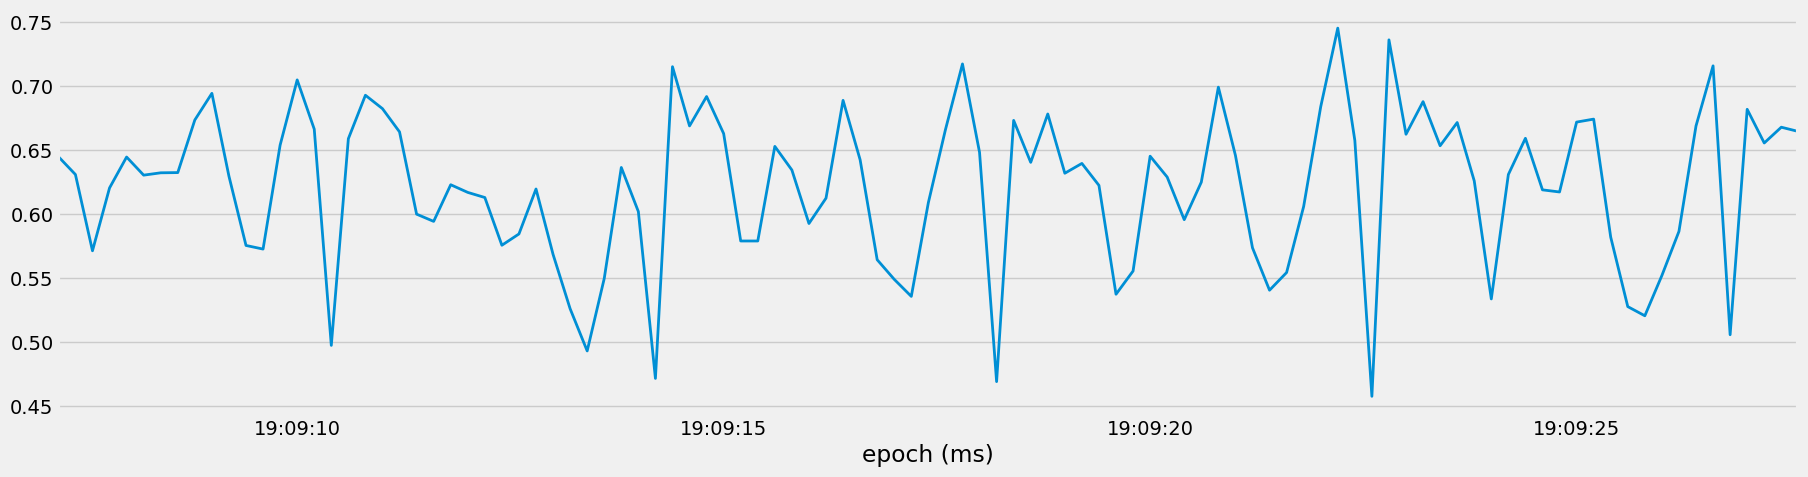

In [11]:
df[df["set"] == 25]["acc_y"].plot()

<Axes: xlabel='epoch (ms)'>

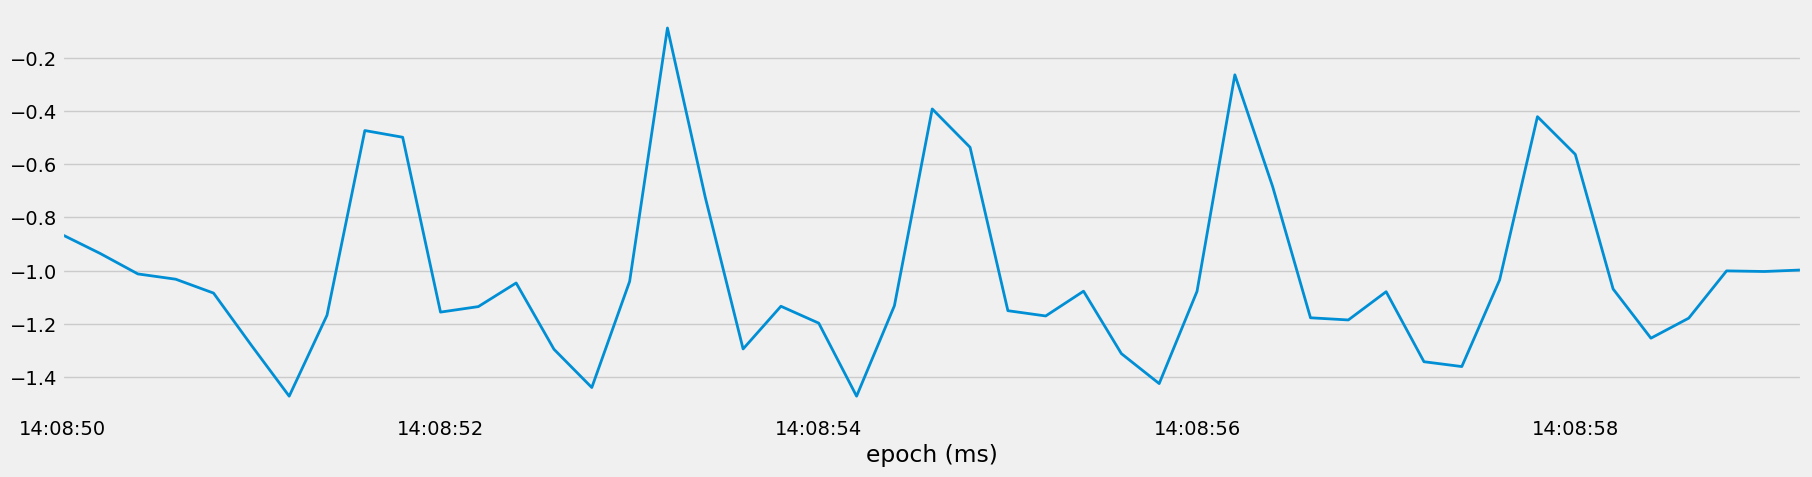

In [12]:
df[df["set"] == 50]["acc_y"].plot()

In [13]:
duration = df[df["set"] == 1].index[-1] - df[df["set"] == 1].index[0]

In [14]:
duration.seconds

16

In [15]:
df['category'] = df['category'].replace({'heavy3': 'heavy', 'medium3': 'medium'})

In [16]:
for s in df["set"].unique():
    start = df[df["set"] == s].index[0]
    stop = df[df["set"] == s].index[-1]
    
    duration = stop - start
    df.loc[df["set"] == s, "duration"] = duration.seconds

In [17]:
duration_df = df.groupby(["category"])["duration"].mean()
duration_df

category
heavy       14.743501
medium      24.942529
sitting     33.000000
standing    39.000000
Name: duration, dtype: float64

In [18]:
duration_df.iloc[0] / 5

np.float64(2.9487001733102254)

In [19]:
duration_df.iloc[1] / 10

np.float64(2.4942528735632186)

In [20]:
df_lowpass = df.copy()

In [21]:
LowPass = LowPassFilter()

In [22]:
fs = 1000 / 200
cutoff = 1.2

In [23]:
df_lowpass = LowPass.low_pass_filter(df_lowpass, "acc_y", fs, cutoff, order=5)


In [24]:
subset = df_lowpass[df_lowpass["set"] == 45]
print(subset["label"].iloc[0])

ohp


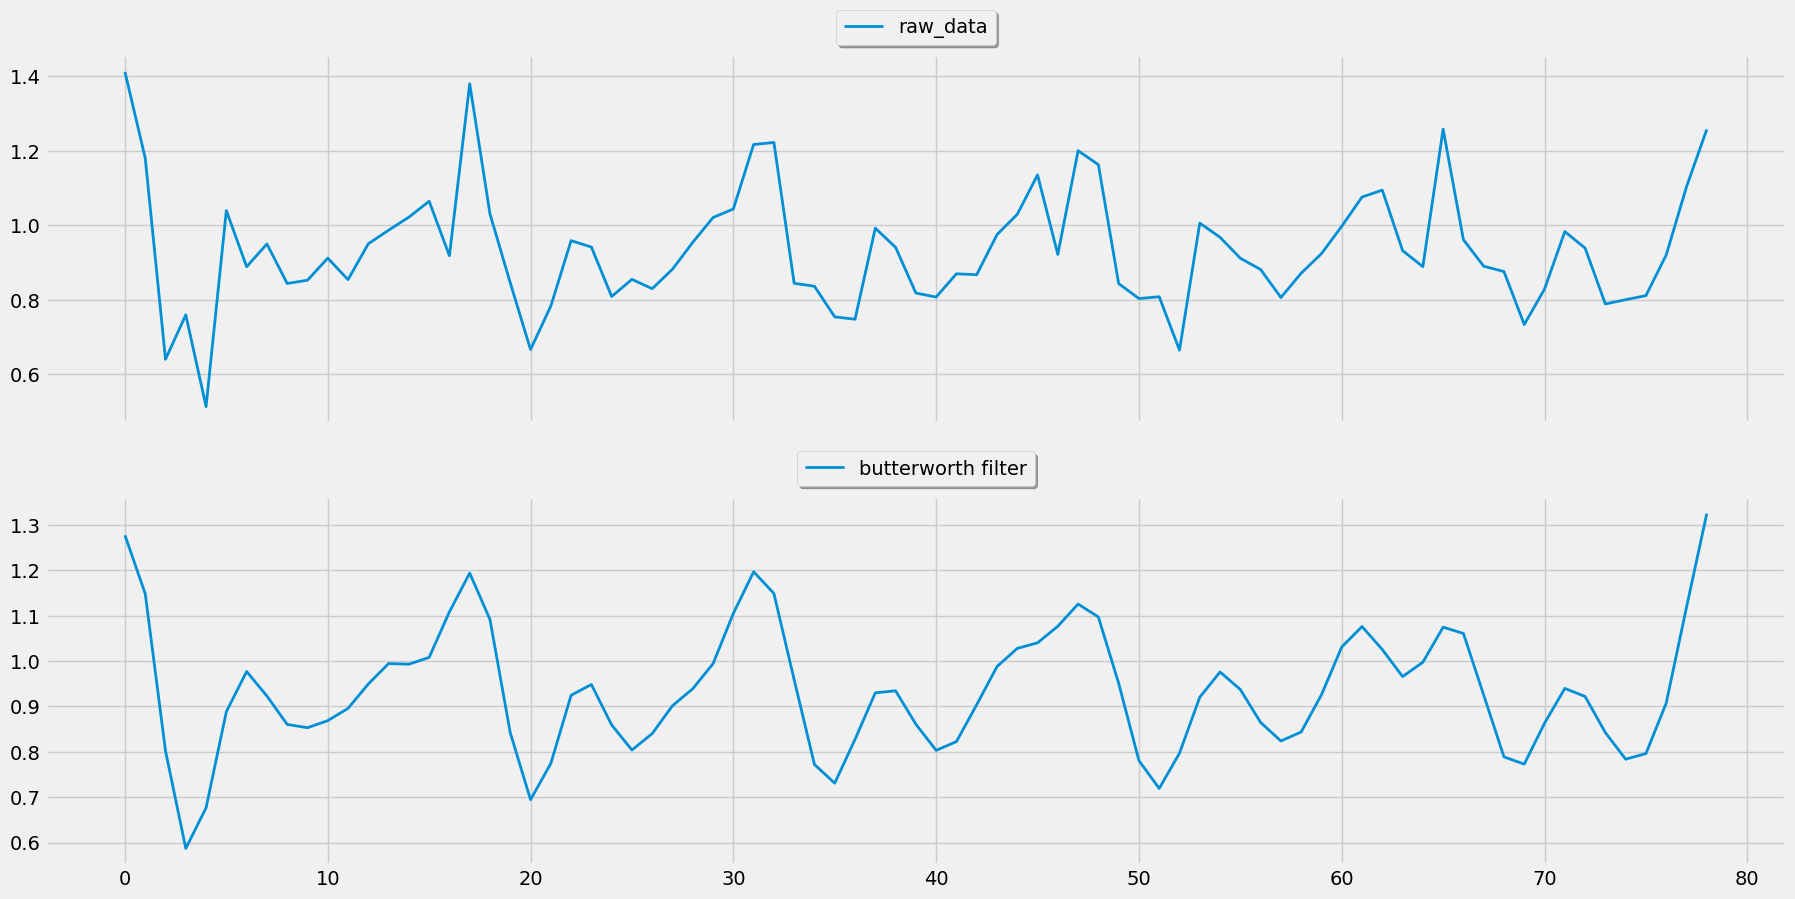

In [25]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))
ax[0].plot(subset["acc_y"].reset_index(drop=True), label="raw_data")
ax[1].plot(subset["acc_y_lowpass"].reset_index(drop=True), label="butterworth filter")
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), fancybox=True, shadow=True)

In [26]:
for col in predictor_columns:
    df_lowpass = LowPass.low_pass_filter(df_lowpass, col, fs, cutoff, order=5)
    df_lowpass[col] = df_lowpass[col + "_lowpass"]
    del df_lowpass[col + "_lowpass"] 

PRINCIPAL COMPONENT ANALYSIS (PCA)

In [27]:
df_pca = df_lowpass.copy()
PCA = PrincipalComponentAnalysis()

pc_values = PCA.determine_pc_explained_variance(df_pca, predictor_columns)

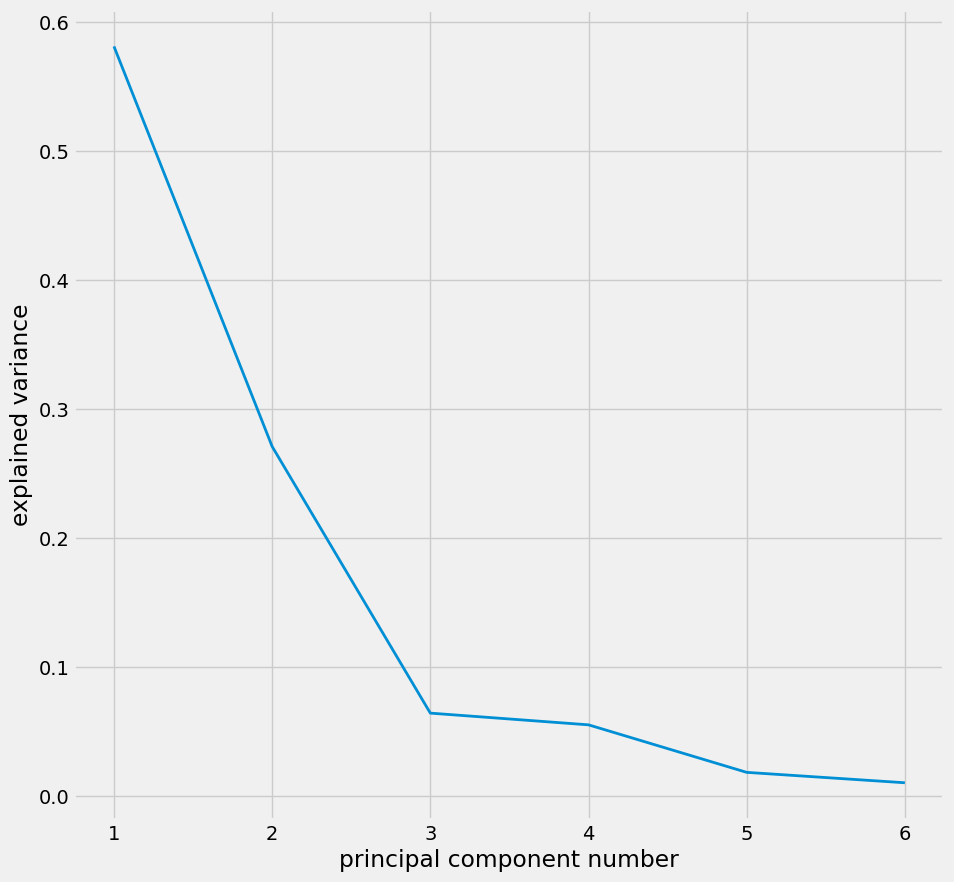

In [28]:
plt.figure(figsize=(10, 10))
plt.plot(range(1, len(predictor_columns) + 1), pc_values)
plt.xlabel("principal component number")
plt.ylabel("explained variance")
plt.show()

In [29]:
df_pca = PCA.apply_pca(df_pca, predictor_columns, 3)

In [30]:
subset = df_pca[df_pca["set"] == 35]

<Axes: xlabel='epoch (ms)'>

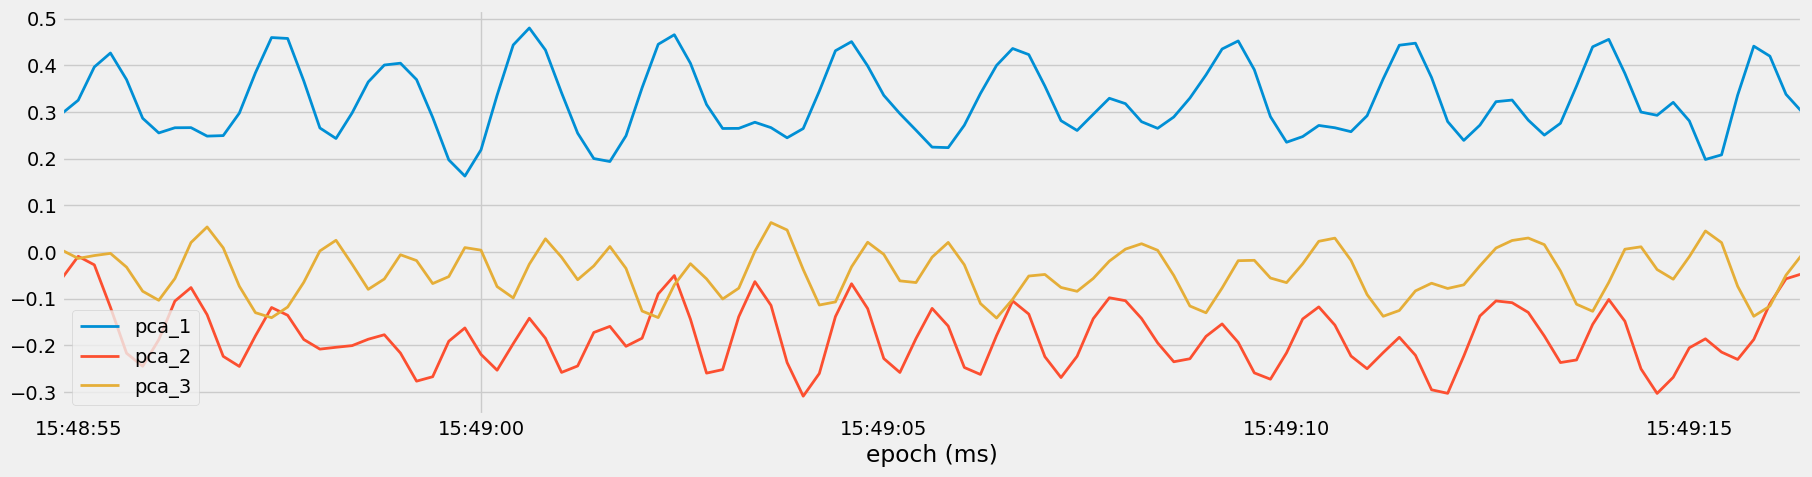

In [31]:
subset[["pca_1", "pca_2", "pca_3"]].plot()

SUM OF SQUARE ATTRIBUTES

In [32]:
df_squared = df_pca.copy()

In [33]:
acc_r = df_squared["acc_x"] ** 2 + df_squared["acc_y"] ** 2 + df_squared["acc_z"] ** 2
gyro_r = df_squared["gyro_x"] ** 2 + df_squared["gyro_y"] ** 2 + df_squared["gyro_z"] ** 2

In [34]:
df_squared["acc_r"] = np.sqrt(acc_r)
df_squared["gyro_r"] = np.sqrt(gyro_r)

In [35]:
subset = df_squared[df_squared["set"] == 14]

array([<Axes: xlabel='epoch (ms)'>, <Axes: xlabel='epoch (ms)'>],
      dtype=object)

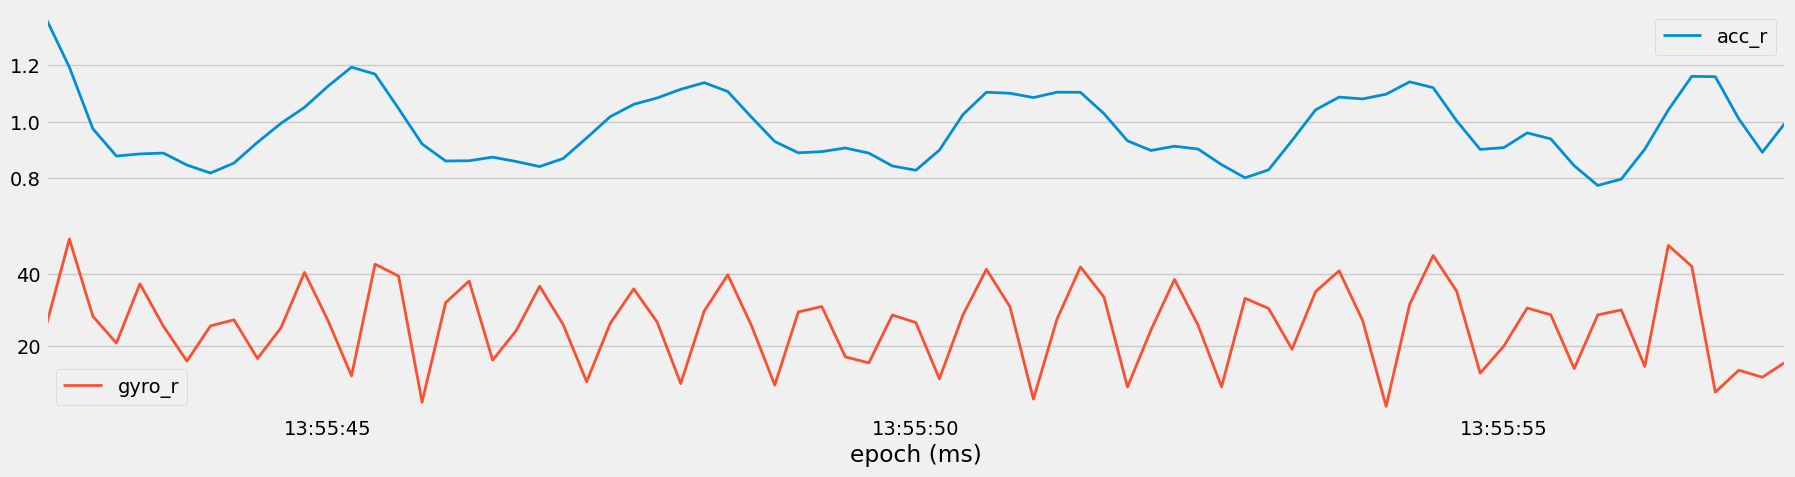

In [36]:
subset[["acc_r", "gyro_r"]].plot(subplots=True)

In [37]:
df_squared

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,duration,pca_1,pca_2,pca_3,acc_r,gyro_r
epoch (ms),,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,B,bench,heavy,30,16.0,0.317491,-0.075816,0.070520,0.979670,3.229288
2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,B,bench,heavy,30,16.0,0.315555,-0.075282,0.070565,0.972630,2.524460
2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,B,bench,heavy,30,16.0,0.314780,-0.081915,0.065980,0.966432,4.741409
2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,B,bench,heavy,30,16.0,0.316880,-0.090205,0.060065,0.969338,4.269510
2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,B,bench,heavy,30,16.0,0.317350,-0.095463,0.063173,0.971528,2.772009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,E,row,medium,90,19.0,-0.346775,-0.147540,-0.051285,0.977783,5.556027
2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,E,row,medium,90,19.0,-0.362725,-0.146231,-0.059154,1.023441,3.727999
2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,E,row,medium,90,19.0,-0.372734,-0.153069,-0.058939,1.054796,2.262446


In [38]:
df_temporal = df_squared.copy()

In [39]:
NumAbs = NumericalAbstraction()

In [40]:
predictor_columns = predictor_columns + ["acc_r", "gyro_r"]

In [41]:
ws = int(1000/200)  # window size in samples (convert to int to avoid pandas error)

In [42]:
for col in predictor_columns:
    df_temporal = NumAbs.abstract_numerical(df_temporal, [col], ws, "mean")
    df_temporal = NumAbs.abstract_numerical(df_temporal, [col], ws, "std")

In [43]:
df_temporal

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_x_temp_mean_ws_5,gyro_x_temp_std_ws_5,gyro_y_temp_mean_ws_5,gyro_y_temp_std_ws_5,gyro_z_temp_mean_ws_5,gyro_z_temp_std_ws_5,acc_r_temp_mean_ws_5,acc_r_temp_std_ws_5,gyro_r_temp_mean_ws_5,gyro_r_temp_std_ws_5
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,B,bench,heavy,30,...,1.500334,1.975086,-0.794137,2.101951,-0.523681,1.250569,0.971920,0.004416,3.507335,0.858825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,E,row,medium,90,...,-11.816937,17.831662,0.603702,5.346850,7.165439,6.227556,1.079434,0.120865,19.162630,14.473459
2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,E,row,medium,90,...,-4.923778,12.693305,-1.469373,3.932028,4.409868,5.078760,1.098084,0.102142,11.768908,10.474589
2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,E,row,medium,90,...,0.697498,4.394449,-2.997093,1.570800,1.931172,2.207628,1.065057,0.082144,5.749964,2.605498


In [44]:
df_temporal_list = []
for s in df_temporal["set"].unique():
    subset = df_temporal[df_temporal["set"] == s].copy()
    for col in predictor_columns:
        subset = NumAbs.abstract_numerical(subset, [col], ws, "mean")
        subset = NumAbs.abstract_numerical(subset, [col], ws, "std")
    df_temporal_list.append(subset)

pd.concat(df_temporal_list)

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_x_temp_mean_ws_5,gyro_x_temp_std_ws_5,gyro_y_temp_mean_ws_5,gyro_y_temp_std_ws_5,gyro_z_temp_mean_ws_5,gyro_z_temp_std_ws_5,acc_r_temp_mean_ws_5,acc_r_temp_std_ws_5,gyro_r_temp_mean_ws_5,gyro_r_temp_std_ws_5
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,B,bench,heavy,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,B,bench,heavy,30,...,1.500334,1.975086,-0.794137,2.101951,-0.523681,1.250569,0.971920,0.004416,3.507335,0.858825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,E,row,medium,90,...,-11.816937,17.831662,0.603702,5.346850,7.165439,6.227556,1.079434,0.120865,19.162630,14.473459
2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,E,row,medium,90,...,-4.923778,12.693305,-1.469373,3.932028,4.409868,5.078760,1.098084,0.102142,11.768908,10.474589
2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,E,row,medium,90,...,0.697498,4.394449,-2.997093,1.570800,1.931172,2.207628,1.065057,0.082144,5.749964,2.605498


In [45]:
df_temporal = pd.concat(df_temporal_list)

In [46]:
df_temporal.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   acc_x                  9009 non-null   float64
 1   acc_y                  9009 non-null   float64
 2   acc_z                  9009 non-null   float64
 3   gyro_x                 9009 non-null   float64
 4   gyro_y                 9009 non-null   float64
 5   gyro_z                 9009 non-null   float64
 6   participant            9009 non-null   object 
 7   label                  9009 non-null   object 
 8   category               9009 non-null   object 
 9   set                    9009 non-null   int64  
 10  duration               9009 non-null   float64
 11  pca_1                  9009 non-null   float64
 12  pca_2                  9009 non-null   float64
 13  pca_3                  9009 non-null   float64
 14  acc_r 

<Axes: xlabel='epoch (ms)'>

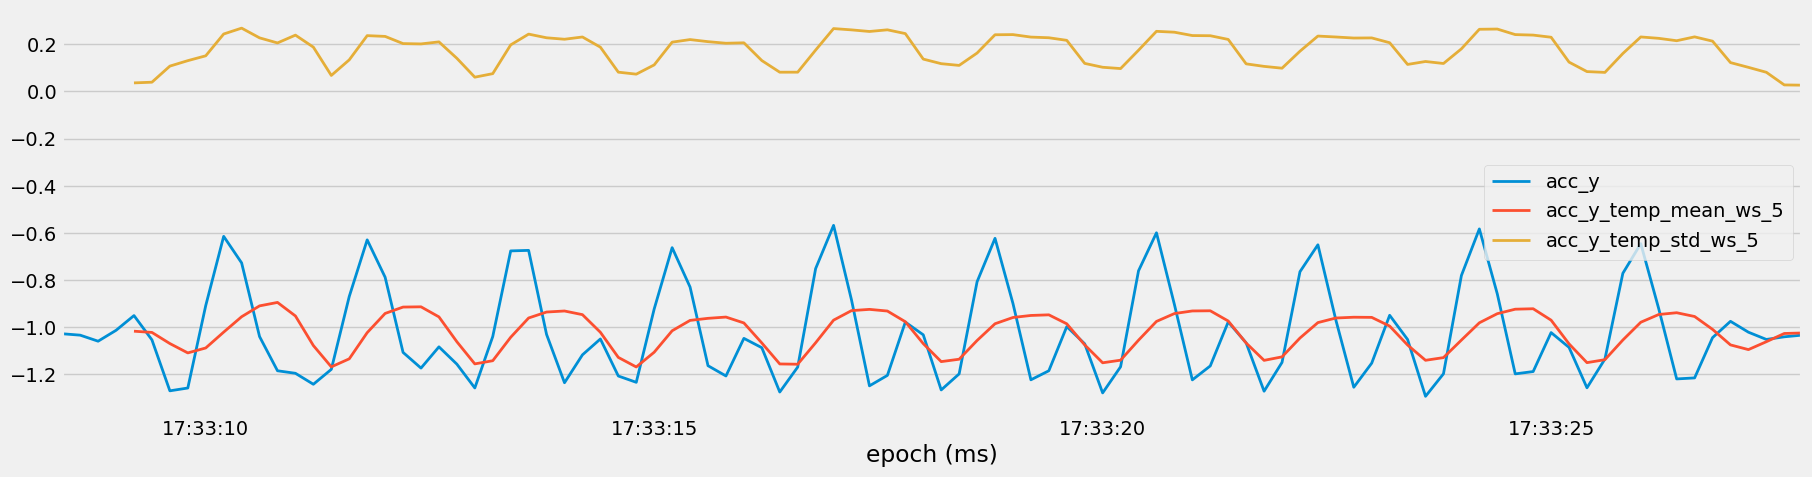

In [47]:
subset[["acc_y", "acc_y_temp_mean_ws_5", "acc_y_temp_std_ws_5"]].plot()

<Axes: xlabel='epoch (ms)'>

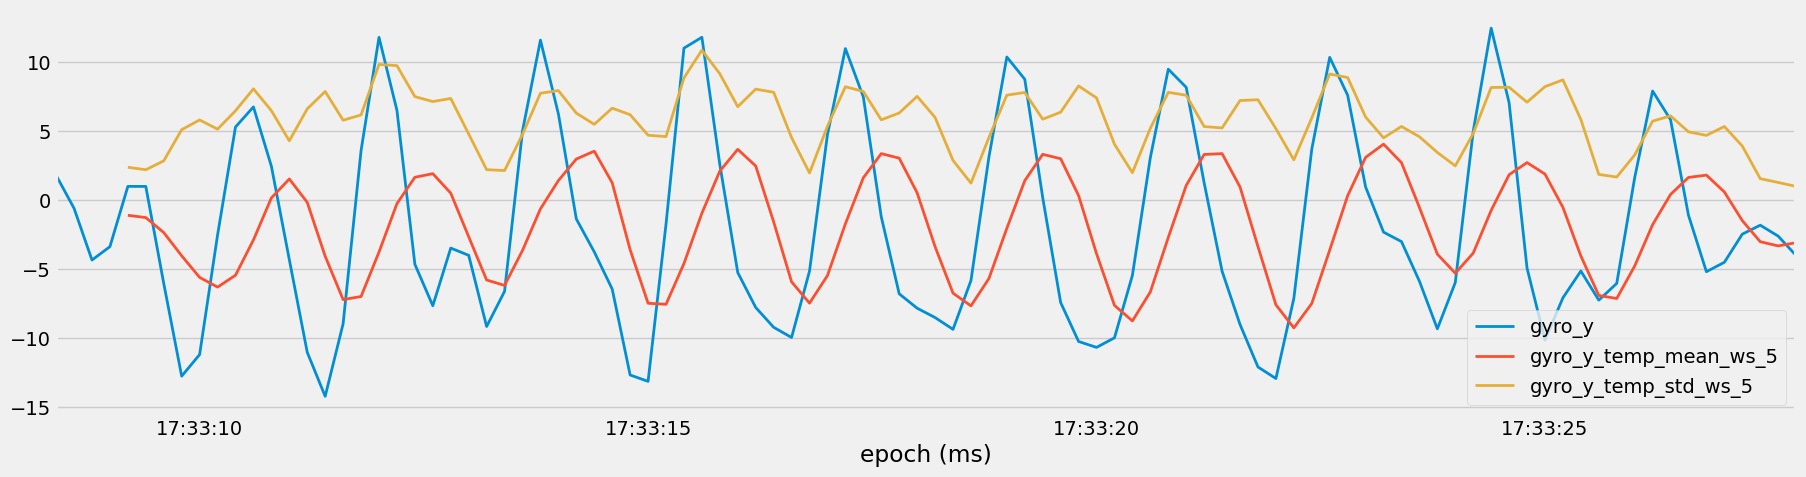

In [48]:
subset[["gyro_y", "gyro_y_temp_mean_ws_5", "gyro_y_temp_std_ws_5"]].plot()

FREQUENCY FEATURES

In [49]:
df_freq = df_temporal.copy().reset_index()

In [50]:
df_freq

,epoch (ms),acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,...,gyro_x_temp_mean_ws_5,gyro_x_temp_std_ws_5,gyro_y_temp_mean_ws_5,gyro_y_temp_std_ws_5,gyro_z_temp_mean_ws_5,gyro_z_temp_std_ws_5,acc_r_temp_mean_ws_5,acc_r_temp_std_ws_5,gyro_r_temp_mean_ws_5,gyro_r_temp_std_ws_5
0,2019-01-11 15:08:05.200,0.013494,0.977001,-0.070995,-1.896395,2.439080,0.939616,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-11 15:08:05.400,0.006869,0.970257,-0.067545,2.129685,0.528678,-1.248135,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-11 15:08:05.600,-0.009603,0.963589,-0.073447,4.151973,-2.092258,-0.929804,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-11 15:08:05.800,-0.022998,0.965441,-0.083731,2.074477,-3.626288,0.880509,B,bench,heavy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-11 15:08:06.000,-0.020032,0.966784,-0.093783,1.041930,-1.219897,-2.260590,B,bench,heavy,...,1.500334,1.975086,-0.794137,2.101951,-0.523681,1.250569,0.971920,0.004416,3.507335,0.858825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9004,2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,E,row,medium,...,-11.816937,17.831662,0.603702,5.346850,7.165439,6.227556,1.079434,0.120865,19.162630,14.473459
9005,2019-01-20 17:33:27.200,-0.042806,-1.020916,-0.057715,-2.514546,-2.449224,1.255524,E,row,medium,...,-4.923778,12.693305,-1.469373,3.932028,4.409868,5.078760,1.098084,0.102142,11.768908,10.474589
9006,2019-01-20 17:33:27.400,-0.047074,-1.051656,-0.066326,-0.673530,-1.799975,1.193779,E,row,medium,...,0.697498,4.394449,-2.997093,1.570800,1.931172,2.207628,1.065057,0.082144,5.749964,2.605498
9007,2019-01-20 17:33:27.600,-0.049361,-1.040440,-0.066542,2.411744,-2.591221,0.659428,E,row,medium,...,2.070162,3.565404,-3.299111,1.294202,0.808352,0.406382,1.029788,0.028075,4.916515,2.490629


In [51]:
FreqAbs = FourierTransformation()

In [52]:
fs = int(1000/200)  # sampling frequency in Hz
ws = int(2800/200)  # window size in samples (convert to int to avoid pandas error)

In [53]:
df_freq = FreqAbs.abstract_frequency(df_freq, ["acc_y"], ws, fs)

In [54]:
df_freq.columns

Index(['epoch (ms)', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'participant', 'label', 'category', 'set', 'duration', 'pca_1', 'pca_2',
       'pca_3', 'acc_r', 'gyro_r', 'acc_x_temp_mean_ws_5',
       'acc_x_temp_std_ws_5', 'acc_y_temp_mean_ws_5', 'acc_y_temp_std_ws_5',
       'acc_z_temp_mean_ws_5', 'acc_z_temp_std_ws_5', 'gyro_x_temp_mean_ws_5',
       'gyro_x_temp_std_ws_5', 'gyro_y_temp_mean_ws_5', 'gyro_y_temp_std_ws_5',
       'gyro_z_temp_mean_ws_5', 'gyro_z_temp_std_ws_5', 'acc_r_temp_mean_ws_5',
       'acc_r_temp_std_ws_5', 'gyro_r_temp_mean_ws_5', 'gyro_r_temp_std_ws_5',
       'acc_y_max_freq', 'acc_y_freq_weighted', 'acc_y_pse',
       'acc_y_freq_0.0_Hz_ws_14', 'acc_y_freq_0.357_Hz_ws_14',
       'acc_y_freq_0.714_Hz_ws_14', 'acc_y_freq_1.071_Hz_ws_14',
       'acc_y_freq_1.429_Hz_ws_14', 'acc_y_freq_1.786_Hz_ws_14',
       'acc_y_freq_2.143_Hz_ws_14', 'acc_y_freq_2.5_Hz_ws_14'],
      dtype='object')

VISUALIZE RESULT

<Axes: >

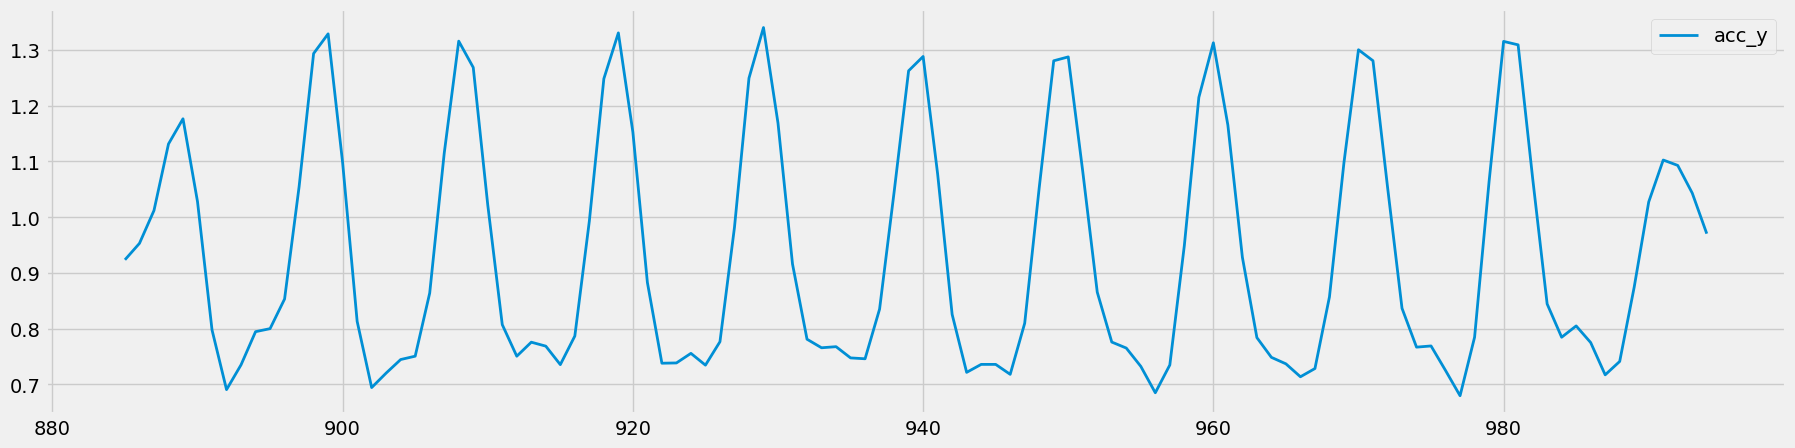

In [55]:
subset = df_freq[df_freq["set"] == 15]
subset[["acc_y"]].plot()


<Axes: >

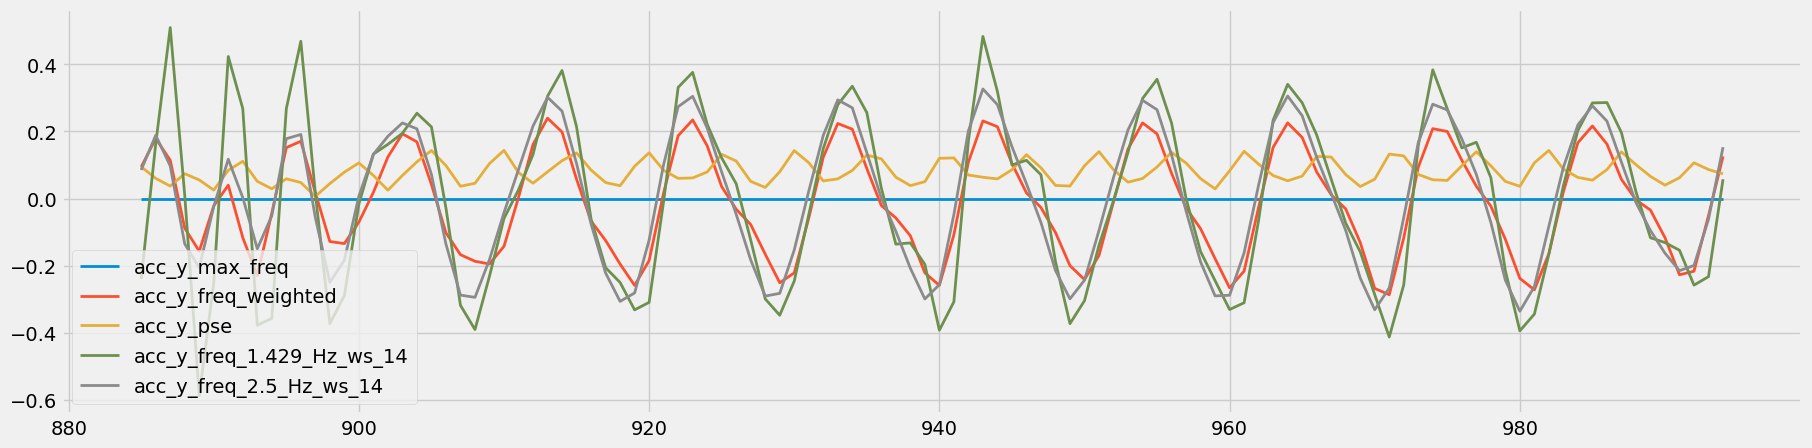

In [56]:
subset[
    [
        "acc_y_max_freq",
        "acc_y_freq_weighted",
        "acc_y_pse",
        "acc_y_freq_1.429_Hz_ws_14",
        "acc_y_freq_2.5_Hz_ws_14",
    ]
].plot()

In [57]:
df_freq_list = []
for s in df_freq["set"].unique():
    print(f"Applying Fourier transformation to set {s}")
    subset = df_freq[df_freq["set"] == s].reset_index(drop=True).copy()
    subset = FreqAbs.abstract_frequency(subset, predictor_columns, ws, fs)
    df_freq_list.append(subset)

Applying Fourier transformation to set 30
Applying Fourier transformation to set 1
Applying Fourier transformation to set 31
Applying Fourier transformation to set 3
Applying Fourier transformation to set 9
Applying Fourier transformation to set 32
Applying Fourier transformation to set 10
Applying Fourier transformation to set 33
Applying Fourier transformation to set 11
Applying Fourier transformation to set 34
Applying Fourier transformation to set 35
Applying Fourier transformation to set 15
Applying Fourier transformation to set 36
Applying Fourier transformation to set 16
Applying Fourier transformation to set 37
Applying Fourier transformation to set 17
Applying Fourier transformation to set 27
Applying Fourier transformation to set 38
Applying Fourier transformation to set 28
Applying Fourier transformation to set 29
Applying Fourier transformation to set 6
Applying Fourier transformation to set 65
Applying Fourier transformation to set 67
Applying Fourier transformation to set

In [58]:
df_freq = pd.concat(df_freq_list).set_index("epoch (ms)", drop=True)

In [59]:
df_freq = df_freq.dropna()

In [60]:
df_freq = df_freq.iloc[::2]


Clustering

In [61]:
df_cluster = df_freq.copy()

In [62]:
cluster_columns = ["acc_x", "acc_y", "acc_z"]
k_values = range(2, 10)
inertias = []

for k in k_values:
    subset = df_cluster[cluster_columns]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset)
    inertias.append(kmeans.inertia_)

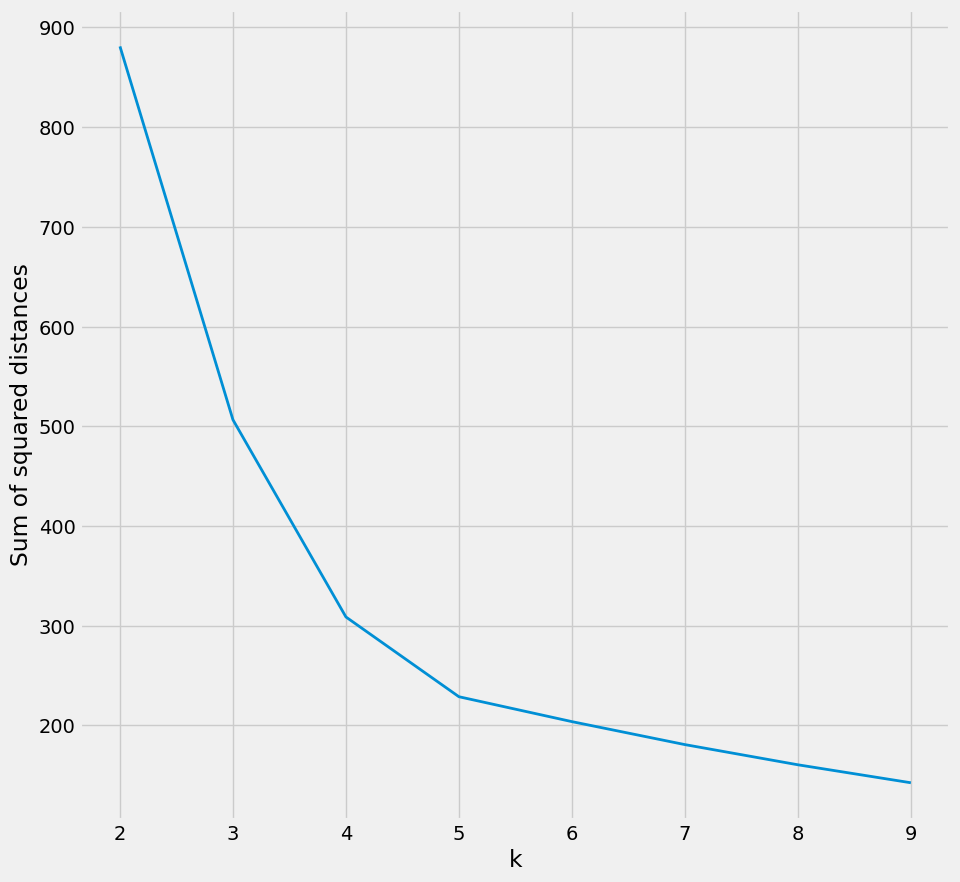

In [63]:
plt.figure(figsize=(10, 10))
plt.plot(k_values, inertias)
plt.xlabel("k")
plt.ylabel("Sum of squared distances")
plt.show()

In [64]:

kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[cluster_columns]
df_cluster["cluster"] = kmeans.fit_predict(subset)

PLOT CLUSTERS

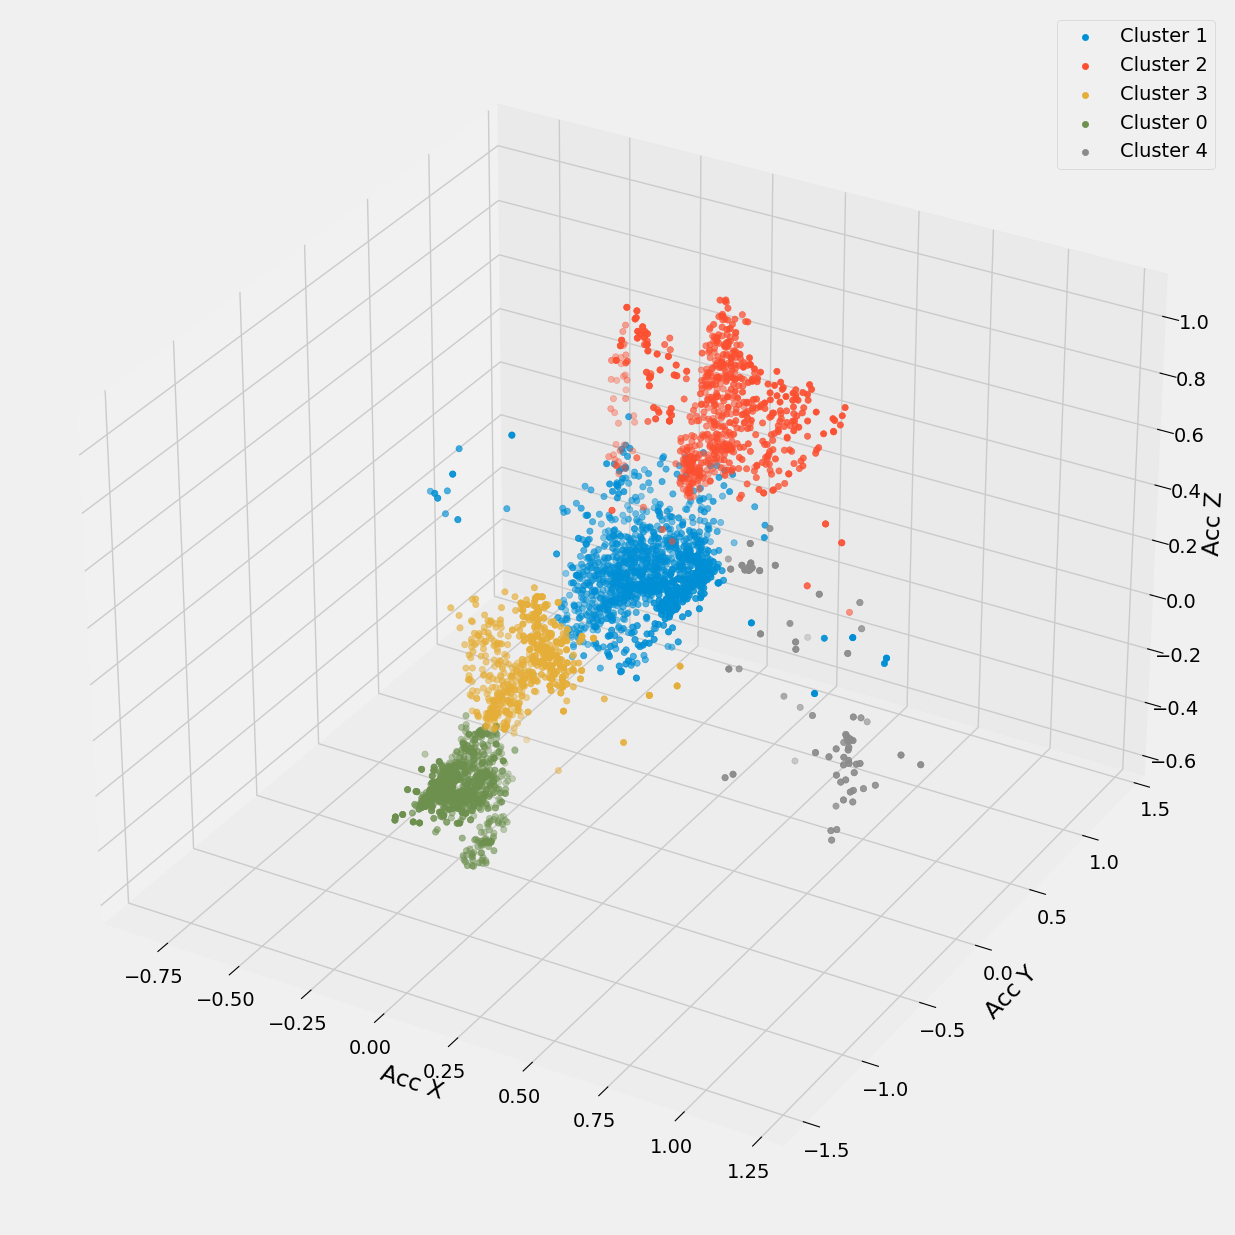

In [65]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection="3d")
for c in df_cluster["cluster"].unique():
    subset = df_cluster[df_cluster["cluster"] == c]
    ax.scatter(subset["acc_x"], subset["acc_y"], subset["acc_z"], label=f"Cluster {c}")
ax.set_xlabel("Acc X")
ax.set_ylabel("Acc Y")
ax.set_zlabel("Acc Z")
plt.legend()
plt.show()

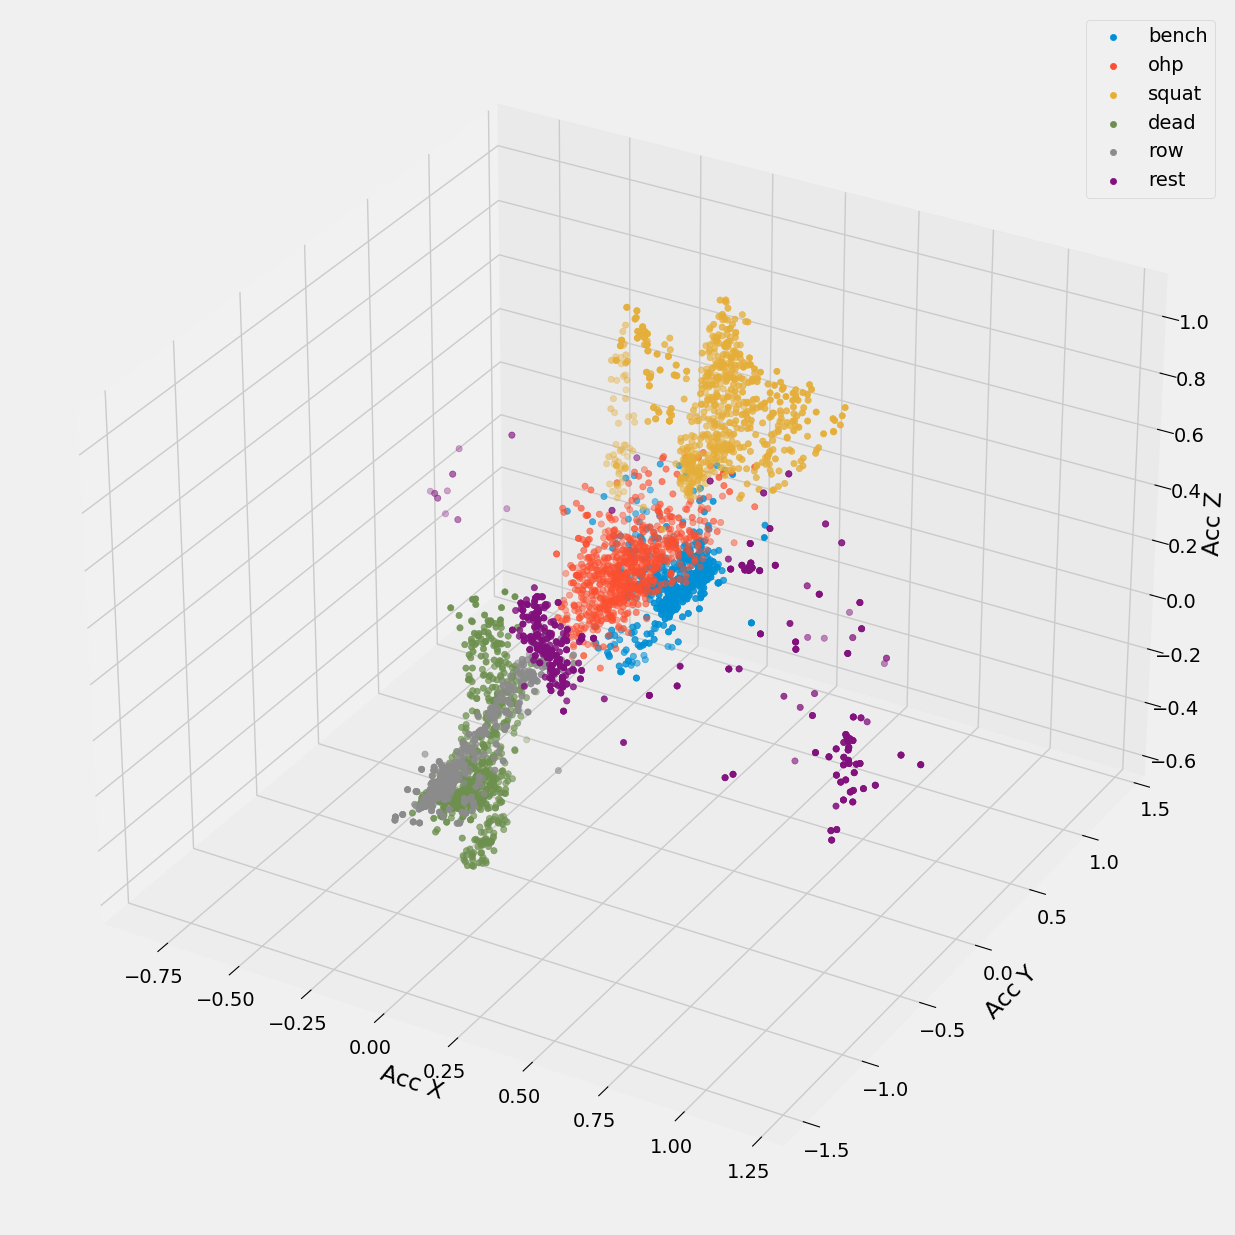

In [66]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection="3d")
for l in df_cluster["label"].unique():
    subset = df_cluster[df_cluster["label"] == l]
    ax.scatter(subset["acc_x"], subset["acc_y"], subset["acc_z"], label=l)
ax.set_xlabel("Acc X")
ax.set_ylabel("Acc Y")
ax.set_zlabel("Acc Z")
plt.legend()
plt.show()

EXPORT THE DATA

In [67]:
df_cluster

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_r_pse,gyro_r_freq_0.0_Hz_ws_14,gyro_r_freq_0.357_Hz_ws_14,gyro_r_freq_0.714_Hz_ws_14,gyro_r_freq_1.071_Hz_ws_14,gyro_r_freq_1.429_Hz_ws_14,gyro_r_freq_1.786_Hz_ws_14,gyro_r_freq_2.143_Hz_ws_14,gyro_r_freq_2.5_Hz_ws_14,cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:08.000,-0.170494,0.888970,-0.172353,-25.990313,-10.162423,25.426906,B,bench,heavy,30,...,0.401838,227.845540,-29.795388,18.195603,0.294594,-24.424951,11.515400,-51.920406,-13.567962,1
2019-01-11 15:08:08.400,-0.027634,0.878027,-0.056321,-4.311919,-1.963210,3.088785,B,bench,heavy,30,...,0.366606,255.346459,-32.701710,-65.942225,-18.156214,5.435095,16.330497,4.416252,-1.494355,1
2019-01-11 15:08:08.800,-0.060139,0.982341,-0.036019,3.691356,-1.273743,-2.492890,B,bench,heavy,30,...,0.432324,256.323480,-40.455694,-30.695845,3.361290,-10.888301,-51.138403,32.709146,-10.263861,1
2019-01-11 15:08:09.200,-0.048152,0.984179,-0.036625,-0.251944,-3.967927,4.930061,B,bench,heavy,30,...,0.479839,247.684640,-30.828083,63.975047,6.797325,14.220152,38.695272,24.992977,-4.795215,1
2019-01-11 15:08:09.600,-0.043981,0.900329,-0.056932,11.319237,5.163204,-10.174713,B,bench,heavy,30,...,0.404515,211.765064,-18.455294,21.941203,9.785602,10.100202,22.696284,-33.412821,-34.036843,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:26.200,0.061740,-0.921306,0.112441,-36.980345,7.916154,15.033379,E,row,medium,90,...,0.327550,360.462098,25.374860,-48.513799,15.078979,-48.324601,-33.271836,-18.850747,-34.950958,3
2019-01-20 17:33:26.600,-0.022066,-1.214770,-0.111567,-4.451577,-1.081130,6.273530,E,row,medium,90,...,0.298590,370.584934,34.584916,-17.726772,-16.241214,29.075325,73.198705,23.422109,10.144916,0
2019-01-20 17:33:27.000,-0.045056,-0.974791,-0.061752,3.273522,-4.487268,0.133850,E,row,medium,90,...,0.211363,315.378553,-32.966667,25.312515,9.456436,-2.814943,-48.443419,-0.900828,-0.225067,0


In [68]:
df_cluster.to_pickle("../../data/interim/03_data_features.pkl")